<a href="https://colab.research.google.com/github/faizakhoeruzzahra/Contoh-Kasus-data-Mining/blob/main/Contoh_Kasus_Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving student-academic-stress-level.csv to student-academic-stress-level.csv


In [2]:
import pandas as pd

df = pd.read_csv("student-academic-stress-level.csv")
df.head()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            140 non-null    object
 1   Your Academic Stage                                                  140 non-null    object
 2   Peer pressure                                                        140 non-null    int64 
 3   Academic pressure from your home                                     140 non-null    int64 
 4   Study Environment                                                    139 non-null    object
 5   What coping strategy you use as a student?                           140 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  140 non-null    object
 7   What would you rat

In [4]:
df['Your Academic Stage'].unique()

array(['undergraduate', 'high school', 'post-graduate'], dtype=object)

In [5]:
df['Study Environment'].unique()

array(['Noisy', 'Peaceful', 'disrupted', nan], dtype=object)

In [6]:
df['What coping strategy you use as a student?'].unique()

array(['Analyze the situation and handle it with intellect',
       'Social support (friends, family)',
       'Emotional breakdown (crying a lot)'], dtype=object)

In [7]:
df['Do you have any bad habits like smoking, drinking on a daily basis?'].unique()

array(['No', 'prefer not to say', 'Yes'], dtype=object)

In [8]:
df['Rate your academic stress index '].unique()

array([5, 3, 4, 2, 1])

In [9]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            139 non-null    object
 1   Your Academic Stage                                                  139 non-null    object
 2   Peer pressure                                                        139 non-null    int64 
 3   Academic pressure from your home                                     139 non-null    int64 
 4   Study Environment                                                    139 non-null    object
 5   What coping strategy you use as a student?                           139 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  139 non-null    object
 7   What would you rate the

In [10]:
print(df.columns)

Index(['Timestamp', 'Your Academic Stage', 'Peer pressure',
       'Academic pressure from your home', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index '],
      dtype='object')


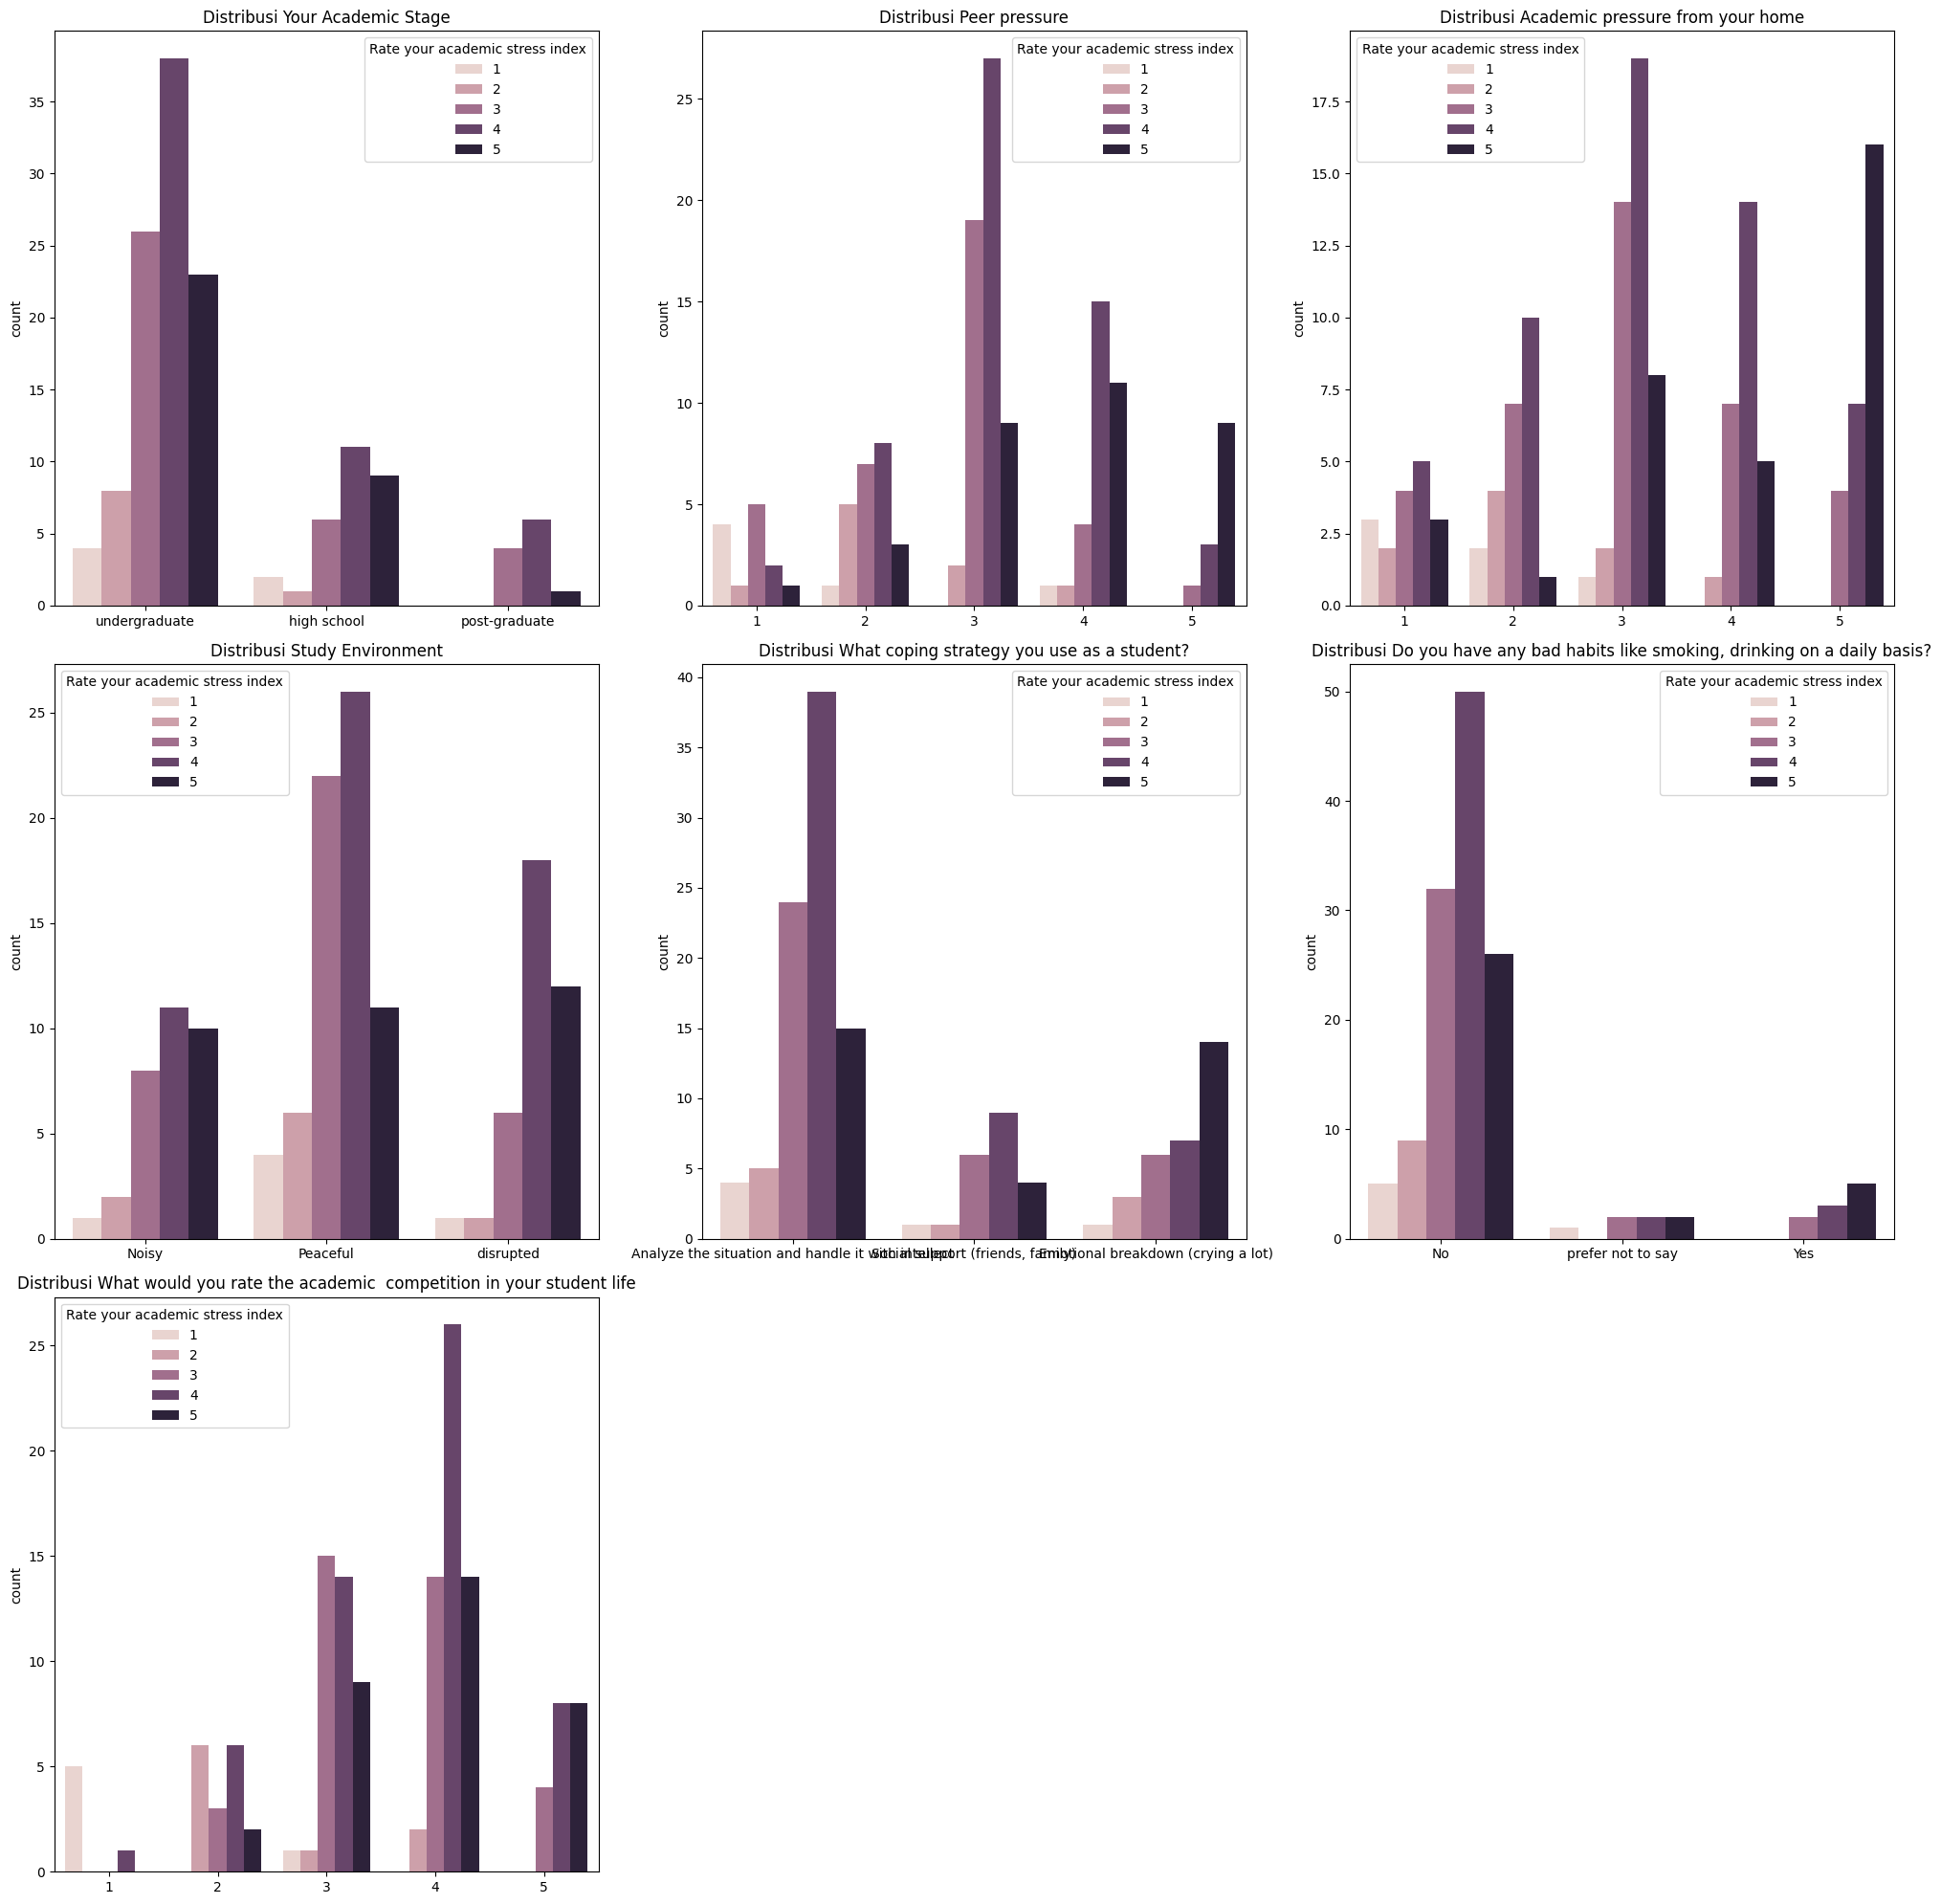

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tentukan fitur yang ingin divisualisasikan (semua fitur kecuali target)
features = df.columns.drop('Rate your academic stress index')

# 2. Atur tata letak bingkai (misal: 6 baris, 4 kolom)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
axes = axes.flatten() # Mengubah matriks posisi menjadi satu deret agar mudah diakses

# 3. Lakukan otomatisasi dengan FOR loop
for i, col in enumerate(features):
    sns.countplot(data=df, x=col, hue='Rate your academic stress index', ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('') # Menghapus label X agar tidak terlalu ramai

# 4. Hapus bingkai kosong jika jumlah fitur tidak pas dengan grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

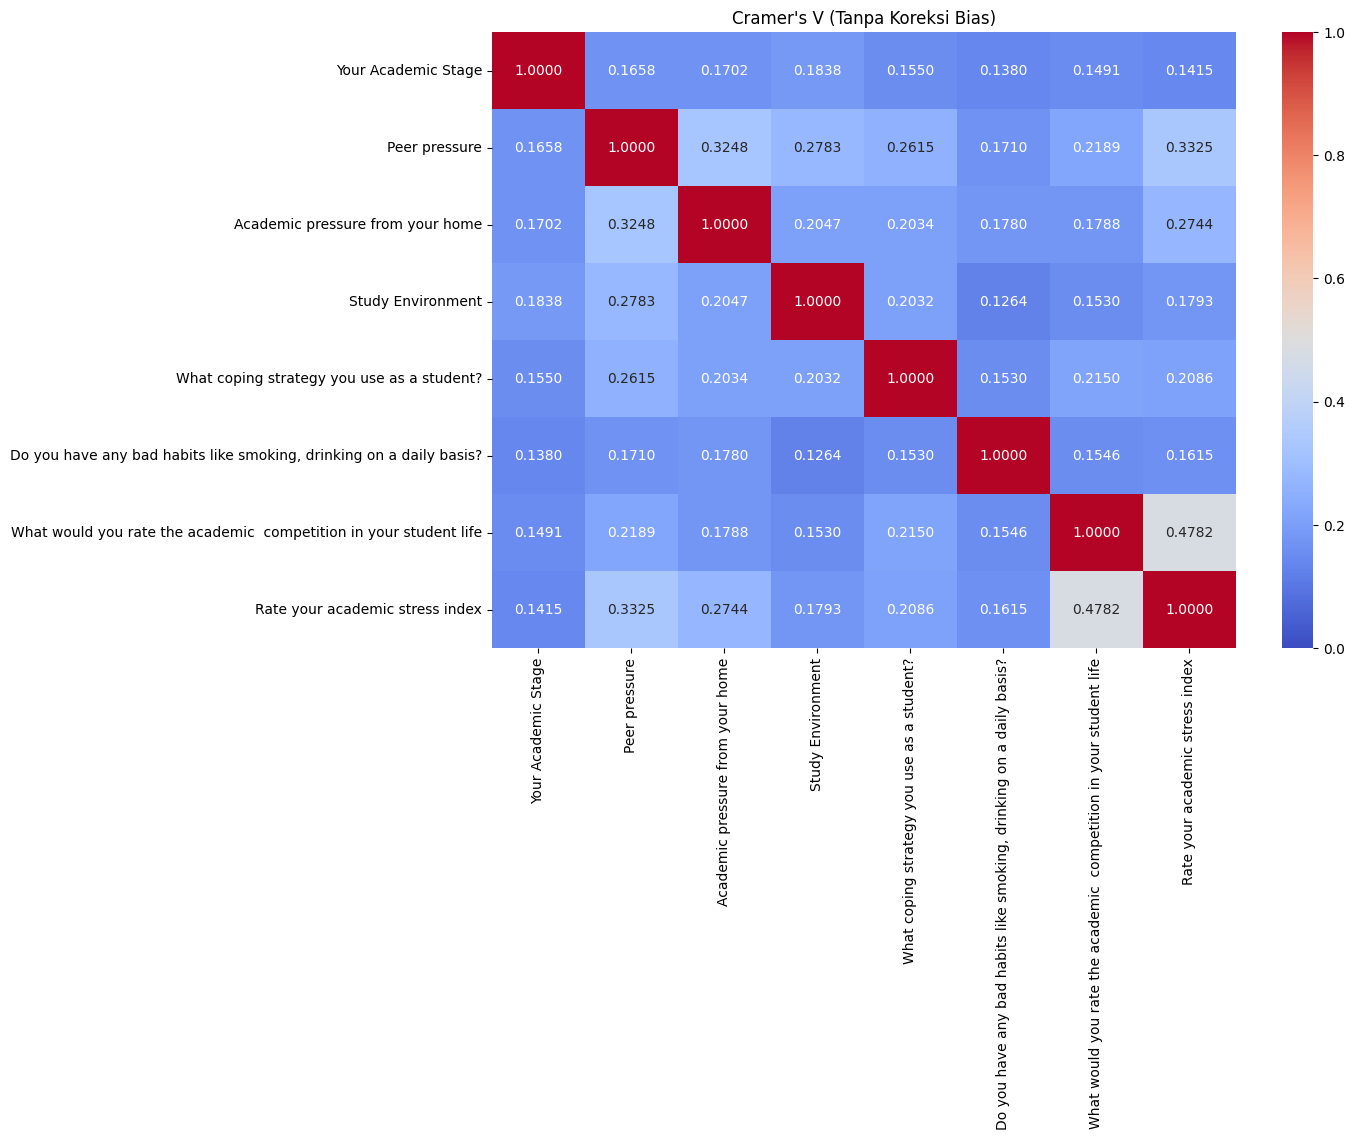

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def get_cramers_v_and_p(x, y):
    # Buat tabel kontingensi
    confusion_matrix = pd.crosstab(x, y)

    # Hitung Chi-Square
    # lambda_='log-likelihood' (G-test) sering lebih stabil untuk multiclass
    chi2, p, dof, ex = chi2_contingency(confusion_matrix)

    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    # Rumus Cramer's V Dasar (Tanpa Koreksi Bias yang merusak nilai kecil)
    # n * (min(r,k) - 1) adalah pembagi standar
    divisor = n * (min(r, k) - 1)

    if divisor == 0:
        return 0.0, 1.0

    v = np.sqrt(chi2 / divisor)
    return v, p

# --- Eksekusi ---
# Pastikan semua kolom target dan fitur sudah menjadi string/object
df_clean = df.copy()
for col in df_clean.columns:
    df_clean[col] = df_clean[col].astype(str)

cols = df_clean.columns
v_matrix = pd.DataFrame(index=cols, columns=cols)
p_matrix = pd.DataFrame(index=cols, columns=cols)

for col1 in cols:
    for col2 in cols:
        v, p = get_cramers_v_and_p(df_clean[col1], df_clean[col2])
        v_matrix.loc[col1, col2] = v
        p_matrix.loc[col1, col2] = p

# Ubah ke float untuk heatmap
v_matrix = v_matrix.astype(float)
p_matrix = p_matrix.astype(float)

# --- Visualisasi ---
plt.figure(figsize=(12, 8))
sns.heatmap(v_matrix, annot=True, cmap='coolwarm', fmt='.4f', vmin=0)
plt.title("Cramer's V (Tanpa Koreksi Bias)")
plt.show()

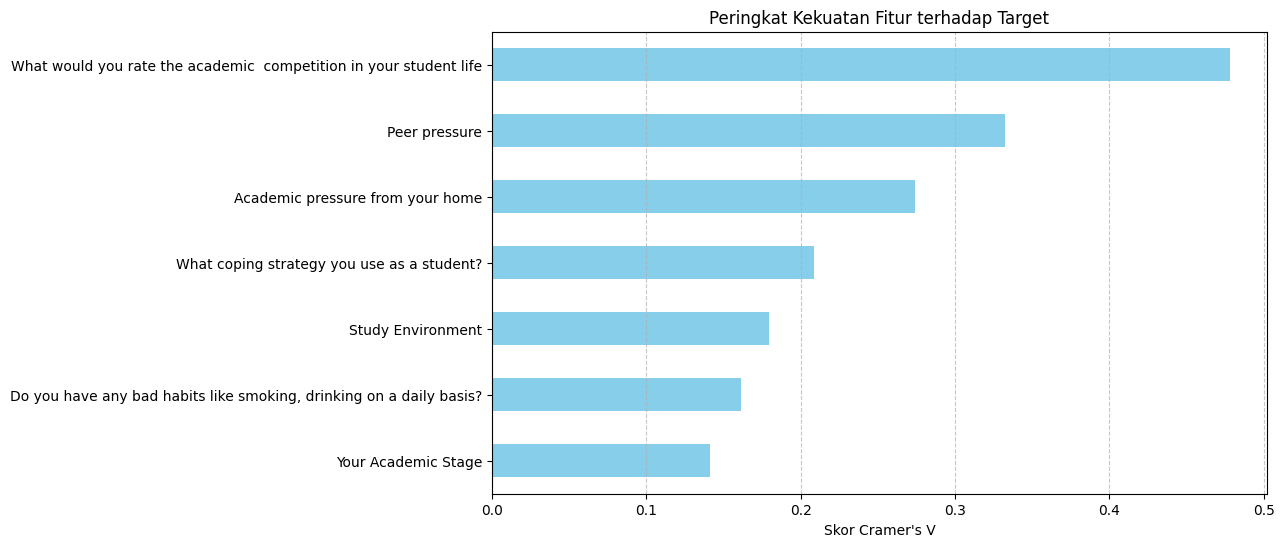

In [20]:
# Mengambil korelasi terhadap target saja (asumsi nama kolom target adalah 'class')
target_corr = v_matrix['Rate your academic stress index'].drop('Rate your academic stress index').sort_values(ascending=True)

plt.figure(figsize=(10, 6))
target_corr.plot(kind='barh', color='skyblue')
plt.title("Peringkat Kekuatan Fitur terhadap Target")
plt.xlabel("Skor Cramer's V")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

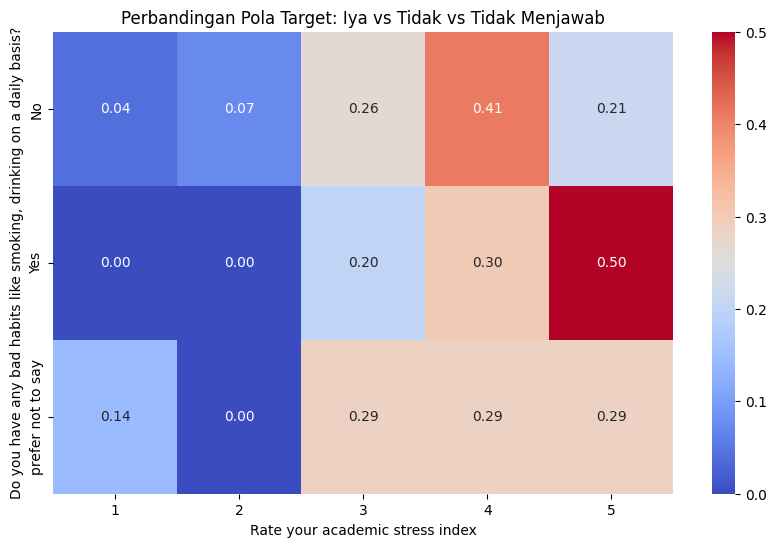

In [22]:
# Membuat tabel perbandingan distribusi target untuk tiap kategori jawaban
perbandingan = pd.crosstab(df['Do you have any bad habits like smoking, drinking on a daily basis?'], df['Rate your academic stress index'], normalize='index')

# Visualisasikan dengan Heatmap agar mudah dibaca
plt.figure(figsize=(10, 6))
sns.heatmap(perbandingan, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Perbandingan Pola Target: Iya vs Tidak vs Tidak Menjawab")
plt.show()

In [24]:
print(df.columns)

Index(['Your Academic Stage', 'Peer pressure',
       'Academic pressure from your home', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index'],
      dtype='object')


In [25]:
df['Your Academic Stage'].unique()

array(['undergraduate', 'high school', 'post-graduate'], dtype=object)

In [26]:
pd.set_option('future.no_silent_downcasting', True)
df['Your Academic Stage']=df['Your Academic Stage'].replace({'high school':0,'undergraduate':1,'post-graduate':2}).infer_objects(copy=False)
df.head()

,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,1,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,1,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,1,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,1,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,1,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [27]:
df['Study Environment'].unique()

array(['Noisy', 'Peaceful', 'disrupted'], dtype=object)

In [28]:
df['Study Environment']=df['Study Environment'].replace({'disrupted':0,'Noisy':1,'Peaceful':2}).infer_objects(copy=False)
df.head()

,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,1,4,5,1,Analyze the situation and handle it with intel...,No,3,5
1,1,3,4,2,Analyze the situation and handle it with intel...,No,3,3
2,1,1,1,2,"Social support (friends, family)",No,2,4
3,1,3,2,2,Analyze the situation and handle it with intel...,No,4,3
4,1,3,3,2,Analyze the situation and handle it with intel...,No,4,5


In [29]:
df['What coping strategy you use as a student?'].unique()

array(['Analyze the situation and handle it with intellect',
       'Social support (friends, family)',
       'Emotional breakdown (crying a lot)'], dtype=object)

In [30]:
kolom_nominal=['What coping strategy you use as a student?','Do you have any bad habits like smoking, drinking on a daily basis?']

df=pd.get_dummies(df,columns=kolom_nominal, drop_first=True, dtype=int)
df.head()

,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What would you rate the academic competition in your student life,Rate your academic stress index,What coping strategy you use as a student?_Emotional breakdown (crying a lot),"What coping strategy you use as a student?_Social support (friends, family)","Do you have any bad habits like smoking, drinking on a daily basis?_Yes","Do you have any bad habits like smoking, drinking on a daily basis?_prefer not to say"
0,1,4,5,1,3,5,0,0,0,0
1,1,3,4,2,3,3,0,0,0,0
2,1,1,1,2,2,4,0,1,0,0
3,1,3,2,2,4,3,0,0,0,0
4,1,3,3,2,4,5,0,0,0,0


In [31]:
df['Rate your academic stress index'].unique()

array([5, 3, 4, 2, 1])

In [34]:
x=df.drop('Rate your academic stress index',axis=1)
y=df['Rate your academic stress index']

In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42,stratify=y)

In [36]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(class_weight='balanced')
model.fit(x_train,y_train)

DecisionTreeClassifier(class_weight='balanced')

In [37]:
from sklearn.metrics import classification_report,accuracy_score
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))
accuracy_score(y_test,y_pred)

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         2
           3       0.50      0.29      0.36         7
           4       0.33      0.55      0.41        11
           5       0.20      0.14      0.17         7

    accuracy                           0.36        28
   macro avg       0.41      0.39      0.39        28
weighted avg       0.34      0.36      0.33        28



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.35714285714285715

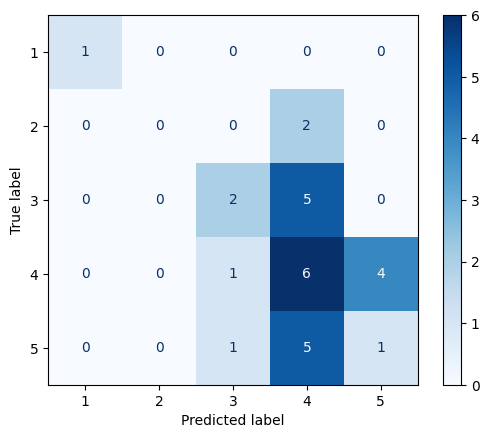

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
disp =ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['1','2','3','4','5'])
disp.plot(cmap='Blues')
plt.show()

In [39]:
df['Rate your academic stress index'].value_counts()

,count
Rate your academic stress index,
4,55
3,36
5,33
2,9
1,6


In [40]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(class_weight='balanced',n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)
y_pred=rf_model.predict(x_test)

In [41]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.2857142857142857
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       1.00      0.50      0.67         2
           3       0.20      0.14      0.17         7
           4       0.25      0.36      0.30        11
           5       0.20      0.14      0.17         7

    accuracy                           0.29        28
   macro avg       0.53      0.43      0.46        28
weighted avg       0.31      0.29      0.28        28



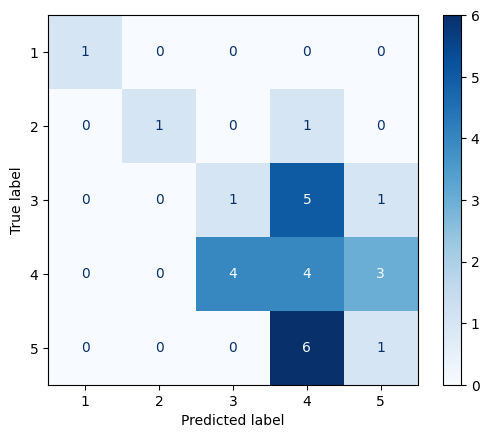

In [42]:
cm=confusion_matrix(y_test,y_pred)
disp =ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['1','2','3','4','5'])
disp.plot(cmap='Blues')
plt.show()

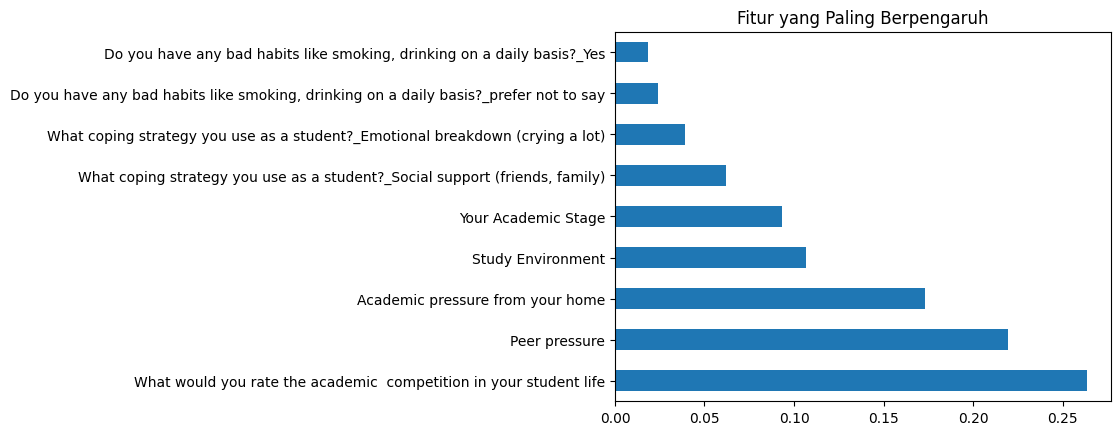

In [43]:
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=x.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Fitur yang Paling Berpengaruh")
plt.show()